In [1]:
# imports

import os 
import requests 
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

Join the data from Part 1 with the data from Part 2 to create a new dataframe.

In [24]:
yelp_df = pd.read_csv('C:/Users/sherr/LHL classwork/LHL-P2/data/yelp_df.csv')
yelp_df

,station_name,timestamp,free_bikes,empty_slots,avg_rrating,avg_rdist,best_rratingname,best_rrating,best_rdist,avg_prating,avg_pdist,best_pratingname,best_prating,best_pdist
0,Chilco & Barclay,2025-04-28T21:24:37.623693+00:00Z,4,13,4.27,375.56,Tre Viet,4.7,421.291392,2.99,1253.77,The Well by Kunye,5.0,777.755119
1,St George & Broadway,2025-04-28T21:24:38.388601+00:00Z,4,9,4.15,476.31,Mercato Di Luigi,4.5,322.184364,2.81,1235.53,Evolution Fitness and Lagree,5.0,1381.878329
2,Britannia Parking Lot,2025-04-28T21:24:38.387061+00:00Z,5,9,4.25,323.79,Magari by Oca,5.0,332.892353,4.00,573.07,Spartacus Gym,4.0,573.065975
3,Morton & Denman,2025-04-28T21:24:37.385717+00:00Z,3,20,4.32,196.19,Noah's Cafe,4.7,155.258150,3.45,1346.82,The Well by Kunye,5.0,913.784194
4,Thornton & National,2025-04-28T21:24:38.387197+00:00Z,6,8,4.13,667.08,Ekki Sushi,4.5,370.940651,4.10,1395.51,Reform Pilates,5.0,1694.888580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253,7th & Heather,2025-04-28T21:24:37.557447+00:00Z,3,15,4.17,454.48,Homura Yakiniku,4.6,479.730380,4.31,908.51,Tone Pilates,5.0,240.888348
254,Union & Dunlevy,2025-04-28T21:24:38.384613+00:00Z,1,13,4.19,470.18,The Darkside,4.7,228.746029,3.77,1133.74,Reform Pilates,5.0,1247.801597
255,Richards & Helmcken,2025-04-28T21:24:37.872076+00:00Z,10,6,4.39,298.50,Okeya Kyujiro,4.9,253.116977,4.10,665.87,Reform Pilates,5.0,1233.184324
256,Keefer & Abbott,2025-04-28T21:24:37.464879+00:00Z,17,11,4.32,330.74,The Magnet,4.7,369.123873,4.39,644.13,Reform Pilates,5.0,512.136972


Provide a visualization that you used as part of your EDA process. Explain the initial pattern or relationship you discoved through this visualization. 

<Axes: >

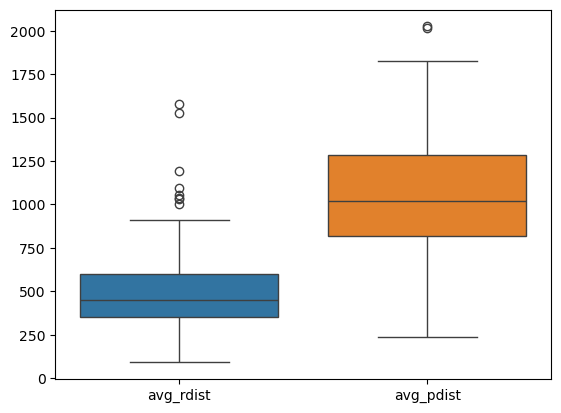

In [51]:
features = yelp_df[['avg_rdist', 'avg_pdist']]
sns.boxplot(data=features)

<Axes: xlabel='avg_rdist', ylabel='Count'>

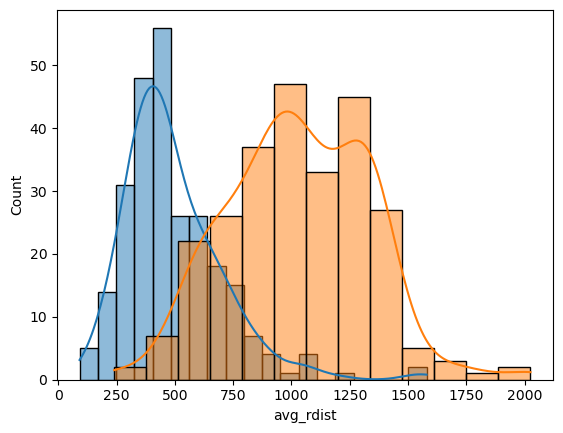

In [81]:
sns.histplot(data=yelp_df, x='avg_rdist', kde=True, bins='auto')
sns.histplot(data=yelp_df, x='avg_pdist', kde=True, bins='auto')

<Axes: xlabel='empty_slots', ylabel='avg_rdist'>

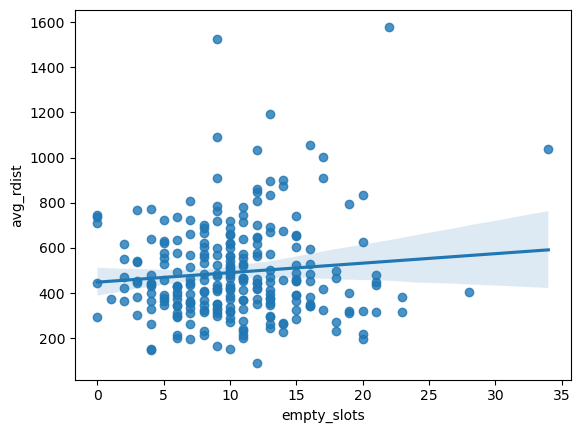

In [105]:
sns.regplot(data=yelp_df, x='empty_slots', y='avg_rdist')

I used a boxplot and a histogram to show the difference in the average restaurant distance and average pilates studio distance. The visualizations show that on average restaurants are closer to bike stations. The minimun distances for restaurants and pilates are similar, but the maximum distance for a pilates studio is further than that for a restaurant. Additionally, average restaurant distances have many more outliers  outliers than pilates studios, and its distribution is unimodal instead of bimodal like that of pilates studios. 

# Database

Put all your results in an SQLite3 database (remember, SQLite stores its databases as files in your local machine - make sure to create your database in your project's data/ directory!)

In [98]:
import sqlite3
from sqlite3 import Error

def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
        print("Connection to SQLite DB successful")
    except Error as e:
        print(f"The error '{e}' occurred")

    return connection

In [99]:
connection = sqlite3.connect('C:/Users/sherr/LHL classwork/LHL-P2/yelp_df.db')

In [100]:
def execute_query(connection, query):
    cursor = connection.cursor()
    try:
        cursor.execute(query)
        connection.commit()
        print("Query executed successfully")
    except Error as e:
        print(f"The error '{e}' occurred")

Look at the data before and after the join to validate your data.

In [101]:
def execute_read_query(connection, query):
    cursor = connection.cursor()
    result = None
    try:
        cursor.execute(query)
        result = cursor.fetchall()
        return result
    except Error as e:
        print(f"The error '{e}' occurred")



select_users = "SELECT * from yelp_df"
users = execute_read_query(connection, select_users)

for user in users:
    print(user)

(0, 'Chilco & Barclay', '2025-04-28T21:24:37.623693+00:00Z', 4, 13, 4.27, 375.56, 'Tre Viet', 4.7, 421.29139219381256, 2.99, 1253.77, 'The Well by Kunye', 5.0, 777.7551194024904)
(1, 'St George & Broadway', '2025-04-28T21:24:38.388601+00:00Z', 4, 9, 4.15, 476.31, 'Mercato Di Luigi', 4.5, 322.18436390074976, 2.81, 1235.53, 'Evolution Fitness and Lagree', 5.0, 1381.8783286768587)
(2, 'Britannia Parking Lot', '2025-04-28T21:24:38.387061+00:00Z', 5, 9, 4.25, 323.79, 'Magari by Oca', 5.0, 332.8923528642424, 4.0, 573.07, 'Spartacus Gym', 4.0, 573.0659750258259)
(3, 'Morton & Denman', '2025-04-28T21:24:37.385717+00:00Z', 3, 20, 4.32, 196.19, "Noah's Cafe", 4.7, 155.2581499436045, 3.45, 1346.82, 'The Well by Kunye', 5.0, 913.7841942041292)
(4, 'Thornton & National', '2025-04-28T21:24:38.387197+00:00Z', 6, 8, 4.13, 667.08, 'Ekki Sushi', 4.5, 370.9406512991455, 4.1, 1395.51, 'Reform Pilates', 5.0, 1694.8885803139272)
(5, 'Burrard & 14th', '2025-04-28T21:24:38.384108+00:00Z', 5, 13, 4.28, 668.9, 